# 04 — The C-vine generator, step by step

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mamadouyamar/CVineMarketGen/blob/main/examples/04_cvine_step_by_step.ipynb)

The four algorithms of the paper one at a time, looking at what each returns
before calling the next. The history is *synthetic*, simulated from a C-vine
with known families, so the selection can be checked against the truth.

Runtime: about 3 minutes (the calibration step).

## Import

In [1]:
import os, sys, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "examples" else os.getcwd()
sys.path.insert(0, ROOT)                 # run from a local clone, from examples/ or the root
try:
    import cvinemarketgen                # local clone or already installed
except ImportError:                      # e.g. on Google Colab
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "git+https://github.com/mamadouyamar/CVineMarketGen.git"], check=True)
    import cvinemarketgen
print("cvinemarketgen", cvinemarketgen.__version__)

from cvinemarketgen import Targets, CVineMarket, CVineGenerator

cvinemarketgen 0.2.0


## A synthetic history with known families

`make_vine_spec` builds a C-vine from a dict of edges `{(i, k): spec}`, with
the paper's indices (tree `k`, variable `i`). Edge `(2, 1)` is a mixture that
produces a sign change; `(3, 1)` a Gumbel 180° (lower tail); `(4, 1)` a weak
Gaussian. `simulate_known_vine` draws 3,000 observations with Johnson SU marginals.

In [2]:
assets = ["U.S. Large Cap", "U.S. Long Treasuries", "Commodities", "Gold"]
table = pd.read_csv(os.path.join(ROOT, "data", "jpm_ltcma_2024.csv"), index_col="Assets").loc[assets]
engine = CVineGenerator(tol_opt=1e-10, n_samples=10000, use_ncs_on_deepertrees=False, use_ncs_on_firsttree=False,
                        use_mixture_on_firsttree=True, use_mixture_on_deepertrees=False, force_try_ncscopula=False,
                        tol_for_optimization_func=1e-6)
edges = {(2, 1): ("mixture", [("clayton", 270, 0.66), ("gumbel", 0, 1.84)], 0.70),
         (3, 1): ("gumbel", 180, 1.38), (4, 1): ("gaussian", 0, 0.05),
         (3, 2): ("gaussian", 0, -0.15), (4, 2): ("gaussian", 0, 0.30), (4, 3): ("gaussian", 0, 0.20)}
jsu = {"U.S. Large Cap": (2.570, 2.179, 3.540, 2.646), "U.S. Long Treasuries": (-0.096, -0.095, 2.279, 2.062),
       "Commodities": (0.611, 0.589, 2.092, 1.774), "Gold": (-0.523, -0.516, 2.893, 2.675)}
spec = engine.make_vine_spec(assets, edges)
hist = engine.simulate_known_vine(spec, jsu, table["Arithmetic Mean"], table["Volatility"], assets, n=3000, seed=1)
print(hist.shape)
engine.true_edge_table(assets, edges)

(3000, 4)


,tree,edge,true family,true parameters
0,1,"U.S. Long Treasuries , U.S. Large Cap",clayton 270° + gumbel 0°,"w=0.7, theta=(0.66, 1.84)"
1,1,"Commodities , U.S. Large Cap",gumbel 180°,theta=1.38
2,1,"Gold , U.S. Large Cap",gaussian 0°,theta=0.05
3,2,"Commodities , U.S. Long Treasuries | U.S. Larg...",gaussian 0°,theta=-0.15
4,2,"Gold , U.S. Long Treasuries | U.S. Large Cap",gaussian 0°,theta=0.3
5,3,"Gold , Commodities | U.S. Large Cap, U.S. Long...",gaussian 0°,theta=0.2


## Step 1 — targets and marginals (Algorithm 1)

`Targets.from_ltcma` with the history: mean, volatility and correlations from
the table, skewness and kurtosis from the history.

In [3]:
t = Targets.from_ltcma(table, assets=assets, history=hist)
t.summary();

Targets for 4 assets (returns layer)
                        mean     vol    skew    kurt
U.S. Large Cap        0.0819  0.1619 -0.5091  3.5815
U.S. Long Treasuries  0.0592  0.1239  0.0987  3.7461
Commodities           0.0531  0.1800 -0.5302  4.3178
Gold                  0.0543  0.1693  0.0928  3.3657

correlation matrix:
                      U.S. Large Cap  U.S. Long Treasuries  Commodities  Gold
Assets                                                                       
U.S. Large Cap                  1.00                 -0.10         0.45  0.03
U.S. Long Treasuries           -0.10                  1.00        -0.23  0.31
Commodities                     0.45                 -0.23         1.00  0.36
Gold                            0.03                  0.31         0.36  1.00

skewness and kurtosis: estimated from the history (3000 observations)


## Step 2 — family selection (Algorithm 3)

`CVineMarket` with `families='auto'` runs the selection on the history at
`fit`. To look inside, call the engine's steps directly: `load_data_and_setup`
then `fit_and_structure_CVine`.

In [4]:
import io, contextlib
with contextlib.redirect_stdout(io.StringIO()):
    setup = engine.load_data_and_setup(t.to_setup_frame(), t.history, assets, higher_moments=t.higher_moments_frame())
    fit = engine.fit_and_structure_CVine(setup)
print("setup keys:", list(setup))
setup["df_target_stats"].round(3)

setup keys: ['ltcma_corr', 'historical_data', 'asset_order', 'targeted_mom1', 'targeted_mom2', 'targeted_mom3', 'targeted_mom4', 'optimal_params', 'df_target_stats']


,Geometric Mean,Volatility,Arithmetic Mean,Variance,Skewness,Kurtosis
U.S. Large Cap,0.069,0.162,0.082,0.026,-0.509,3.581
U.S. Long Treasuries,0.051,0.124,0.059,0.015,0.099,3.746
Commodities,0.037,0.180,0.053,0.032,-0.530,4.318
Gold,0.040,0.169,0.054,0.029,0.093,3.366


The Johnson SU parameters fitted to the standardized targets:

In [5]:
setup["optimal_params"]

,a,b,c,d,fun,Distr
U.S. Large Cap,3.782151,3.022969,4.326288,2.973263,1.407767e-12,JSU
U.S. Long Treasuries,-0.195520,-0.194775,2.621291,2.425784,2.365245e-11,JSU
Commodities,0.890230,0.844279,2.387337,2.026651,2.041324e-11,JSU
Gold,-0.365994,-0.364456,3.570962,3.413250,8.908309e-12,JSU


The classification of each first-tree pair, `(l, u, s, m)`, read from its exceedance curve (`s = -11` means inconclusive tiebreakers):

In [6]:
fit["trees_prespecification"]["1"]

,lower_tail_dependence,upper_tail_dependence,target_correlation_sign,monotone_dependence
U.S. Long Treasuries,False,True,-1.0,-1.0
Commodities,True,False,1.0,1.0
Gold,False,True,1.0,-1.0


The selected families, to compare with the true table above. Gold, a near-independent pair, is not identifiable and gets a mixture at the right level.

In [7]:
engine.selected_edge_table(assets, fit)

,tree,edge,selected family,parameters
0,1,"U.S. Long Treasuries , U.S. Large Cap",clayton 270° + gumbel 0°,"w=0.69, theta=(0.608, 1.948)"
1,1,"Commodities , U.S. Large Cap",gumbel 180°,theta=1.396
2,1,"Gold , U.S. Large Cap",clayton 180° + gumbel 90°,"w=0.15, theta=(0.588, 1.000)"
3,2,"Commodities , U.S. Long Treasuries | U.S. Larg...",gaussian 0°,theta=-0.142
4,2,"Gold , U.S. Long Treasuries | U.S. Large Cap",gaussian 0°,theta=0.293
5,3,"Gold , Commodities | U.S. Large Cap, U.S. Long...",gaussian 0°,theta=0.174


The h-function values propagated to the second tree (conditional pseudo-observations):

In [8]:
fit["trees_hfunc"]["1"].head()

,2|1,3|1,4|1
0,0.732334,0.000058,0.159180
1,0.105027,0.265966,0.172250
2,0.541213,0.417813,0.675310
3,0.881978,0.023764,0.651329
4,0.560917,0.144756,0.175526


## Step 3 — calibration to the target correlations (Algorithm 4)

Variable by variable, the copula parameters are re-optimized so that the
simulated correlations hit the targets, keeping the selected families. This is
the slow step.

In [9]:
t0 = time.time()
with contextlib.redirect_stdout(io.StringIO()):
    vine = engine.run_vine_optimization(setup, fit)
print(f"{time.time() - t0:.0f} s")
engine.selected_edge_table(assets, fit, vine)

203 s


,tree,edge,selected family,parameters
0,1,"U.S. Long Treasuries , U.S. Large Cap",clayton 270° + gumbel 0°,"w=0.72, theta=(0.638, 1.939)"
1,1,"Commodities , U.S. Large Cap",gumbel 180°,theta=1.381
2,1,"Gold , U.S. Large Cap",clayton 180° + gumbel 90°,"w=0.20, theta=(0.602, 1.021)"
3,2,"Commodities , U.S. Long Treasuries | U.S. Larg...",gaussian 0°,theta=-0.201
4,2,"Gold , U.S. Long Treasuries | U.S. Large Cap",gaussian 0°,theta=0.314
5,3,"Gold , Commodities | U.S. Large Cap, U.S. Long...",gaussian 0°,theta=0.521


## Step 4 — scenario generation with accept-reject (Algorithm 5)

Draw 25,000 scenarios, re-fit the marginals on the draw, accept if the moments
and correlations meet the tolerances.

In [10]:
with contextlib.redirect_stdout(io.StringIO()):
    sims, calib, targets = engine.run_multi_year_simulation(vine, n_year=1, n_per_year=25000, corr_tol=0.05)
X = sims[0]
calib[0].iloc[:, :12].round(4)

,mean (target),mean (calibrated),diff mean,volatility (target),volatility (calibrated),diff volatility,skewness (target),skewness (calibrated),diff skewness,kurtosis (target),kurtosis (calibrated),diff kurtosis
U.S. Large Cap,0.081907,0.0819,-0.0,0.161853,0.1619,0.0,-0.509086,-0.5091,0.0,3.581489,3.5815,0.0
U.S. Long Treasuries,0.059175,0.0592,-0.0,0.123919,0.1239,0.0,0.098696,0.0987,0.0,3.746148,3.7461,0.0
Commodities,0.05306,0.0531,0.0,0.180031,0.1800,0.0,-0.530238,-0.5302,0.0,4.317763,4.3178,0.0
Gold,0.054329,0.0543,-0.0,0.169256,0.1693,0.0,0.092819,0.0928,0.0,3.365687,3.3657,-0.0


## The same in three lines with the user-facing class

`CVineMarket` wraps the four steps; `edges`, `marginals`, `diagnostics` and
`plot_exceedance` expose what we just looked at.

In [11]:
cv = CVineMarket(t, central="U.S. Large Cap", families="auto").fit()
cv.edges

,tree,edge,selected family,parameters
0,1,"U.S. Long Treasuries , U.S. Large Cap",clayton 270° + gumbel 0°,"w=0.70, theta=(0.629, 1.937)"
1,1,"Commodities , U.S. Large Cap",gumbel 180°,theta=1.376
2,1,"Gold , U.S. Large Cap",clayton 180° + gumbel 90°,"w=0.23, theta=(0.600, 1.035)"
3,2,"Commodities , U.S. Long Treasuries | U.S. Larg...",gaussian 0°,theta=-0.196
4,2,"Gold , U.S. Long Treasuries | U.S. Large Cap",gaussian 0°,theta=0.314
5,3,"Gold , Commodities | U.S. Large Cap, U.S. Long...",gaussian 0°,theta=0.493


In [12]:
Xc = cv.simulate(25000, seed=1)
cv.diagnostics(Xc).summary();

25000 simulated observations (returns layer)
                      mean target  mean simulated  mean diff  vol target  vol simulated  vol diff  skew target  skew simulated  skew diff  kurt target  kurt simulated  kurt diff
U.S. Large Cap             0.0819          0.0819       -0.0      0.1619         0.1619       0.0      -0.5091         -0.5091       -0.0       3.5815          3.5818     0.0004
U.S. Long Treasuries       0.0592          0.0592       -0.0      0.1239         0.1239       0.0       0.0987          0.0987        0.0       3.7461          3.7465     0.0004
Commodities                0.0531          0.0531        0.0      0.1800         0.1800       0.0      -0.5302         -0.5303       -0.0       4.3178          4.3183     0.0005
Gold                       0.0543          0.0543        0.0      0.1693         0.1693       0.0       0.0928          0.0928        0.0       3.3657          3.3660     0.0003

max |diff| per moment: mean 1.6e-08, vol 3.6e-06, skew 3.2e-05, 

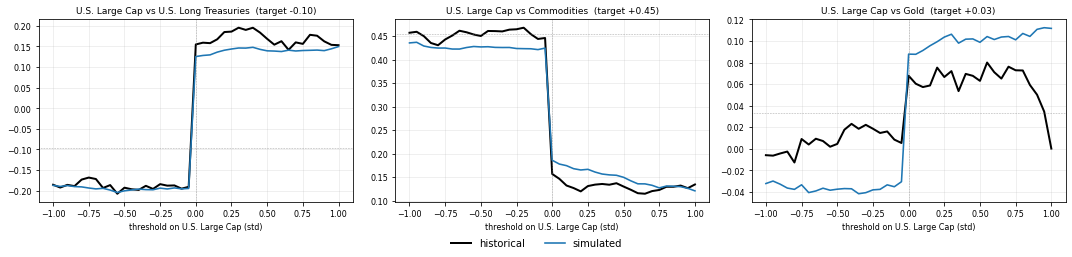

In [13]:
cv.plot_exceedance(Xc);